# Preference for Experimentation v2: Dynamic Programming

Julian Hsu

Initial version: 2026-06-16

## Motivation

The v1 notebook showed that a myopic agent — one that minimises a static loss function with fixed λ (variance aversion) and η (experimentation incentive) — cannot produce the right dynamics. This is because the changing in the inputs of the statistics I am using to summarize beliefs are insufficient. So placing static weights on them generates odd resultsd. Sepcifically, that they will continue to experiment even after they have enough data to realize the truth. 

The fix is to solve the **infinite-horizon discounted dynamic programming problem** directly. The agent now accounts for the future value of information when choosing how much to experiment today.

## Model Setup

Each period $t$, the agent allocates proportion $p_t \in [0,1]$ to the treatment arm and $(1-p_t)$ to control. With $n$ users per round:

- $n_T = \text{round}(p_t \cdot n)$ observations go to treatment
- $n_C = n - n_T$ observations go to control

### Gaussian Normal-Normal Conjugate

The agent maintains Bayesian posteriors over each arm's mean:
$$\theta_i \sim \mathcal{N}(m_i, \, 1/\tau_i)$$

After $n_i$ cumulative observations, the posterior updates as:
$$\tau_i^{\text{new}} = \tau_i + n_i^{\text{new}} / \sigma^2, \qquad m_i^{\text{new}} = \frac{\tau_i m_i + (n_i^{\text{new}}/\sigma^2)\,\bar{y}_i^{\text{new}}}{\tau_i^{\text{new}}}$$

### State

The payoff each period is $p\,m_T + (1-p)\,m_C = m_C + p\,\Delta m$ where $\Delta m = m_T - m_C$. The argmax over $p$ depends only on $\Delta m$ (and the precisions), so we track the **state** $(\Delta m,\, n_T,\, n_C)$. The depth $d = (n_T + n_C)/n$ is implicit in the state; $n_C$ is no longer determined by a period index.

### Law of Motion

Precision evolves **deterministically**:
$$\tau_{i}^{\text{new}} = \tau_{i} + \Delta n_i / \sigma^2$$

The posterior mean difference evolves **stochastically** as a martingale:
$$\Delta m^{\text{new}} \mid \Delta m,\, p \;\sim\; \mathcal{N}\!\left(\Delta m,\; \underbrace{\frac{1}{\tau_T} - \frac{1}{\tau_T^{\text{new}}}}_{\text{treatment learning}} + \underbrace{\frac{1}{\tau_C} - \frac{1}{\tau_C^{\text{new}}}}_{\text{control learning}}\right)$$

The noise variance is exactly the total posterior variance reduced this period — zero when $p=0$ or $p=1$ for the non-allocated arm.

### Bellman Equation

The **infinite-horizon** Bellman equation for the stationary value function $V^*$:

$$V^*(\Delta m,\, n_T,\, n_C) = \max_{p \in P} \left\{ p\,\Delta m + \gamma\, \mathbb{E}\left[V^*(\Delta m',\, n_T + \Delta n_T,\, n_C + \Delta n_C)\right] \right\}$$

We solve via **fixed-point (value iteration)**: initialise $V^0 = 0$ and iterate
$$V^{k+1} = \mathcal{T}[V^k] \quad \text{until} \quad \|V^{k+1} - V^k\|_\infty < \varepsilon$$

The operator $\mathcal{T}$ is a contraction with modulus $\gamma$, so convergence is guaranteed. In practice, states with $n_T + n_C \ge N_{\max} \cdot n$ are treated as terminal ($V = 0$), which is accurate for $\gamma \le 0.9$ since $\gamma^{N_{\max}} \approx 0$.

The expectation over $\Delta m'$ is computed with **Gauss-Hermite quadrature** (10 nodes).

### Discount Factor

The sole free parameter is $\gamma \in [0,1)$:
- $\gamma = 0$: fully myopic — no value to learning; agent acts on current posterior only
- $\gamma \to 1$: patient agent; exploration has high option value


**Caring about the future means experimentation**
Only organizations that care about the future will experiment. With a simulation exercise, we can show that the more agents care about their future outcomes, the more they experiment and the greater their outcomes.

Here is the simulation notebook () and a technical description of the setup:

In simulations, I look at an agent that does not know how to allocate treatment between control or treatment. It does not know which one is best, but whenever they split traffic between control and treatment it starts to learn which is better. In other words, the agent cares about:

(today's payoff) + B (tomorrow's payoff)

Agents that care a lot about future payoffs (high value of B) immediately do and continue to experiment. This would be like conducting a standard AB test and following up with a holdout. This means they learn quickly and then continue to learn, thereby improving their outcomes. 

Caveats: I have tweaked the parameters to make this story more clear. The most significant one is that initial beliefs were wrong. If instead initial beliefs were right that treatment was better, then the experimenting agent would be worse off. 
The parameters are hypothetical and not data-driven. Estimating the beliefs, preference for the future (B), and others falls in structural estimation. 


Personal and brief technical note: I had a lot of fun setting up this dynamic programming problem!
I used a common approach called contraction mapping to solve for how the agent should allocate treatment. Unlike reinfocement learning (RL) which uses parameter values to figure out the optimal action, contraction mapping is used in economics to solve the opposite problem: we assume the optimal policy, but need to estimate the parameters that govern it. Therefore, solving the dynamic programming problem is akin to "inverse RL." Contraction mapping is just one of these approaches. I was really excited to tackle again since grad school.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss

np.random.seed(42)

## DGP and Prior Parameters

The agent never observes `true_effect` or `true_control` directly.

In [10]:
# True DGP (never observed by agent)
true_effect  =  3.0   # treatment arm mean
true_control =  0.0   # control arm mean
sigma2       = 75.0   # observation noise variance — larger = noisier data = slow learning
n_per_round  = 10     # users per period

# Agent's prior: N(m0, 1/tau0) for each arm
# prior_var and sigma2 are independent:
#   large sigma2   → noisy observations → precision accumulates slowly
#   large prior_var → diffuse prior → agent starts very uncertain
# Both large → slow learning.
m0        = 0.2
prior_var = 150.0            # prior variance (independent of observation noise)
tau0      = 1.0 / prior_var  # prior precision

# Coarse allocation grid: 5 values {0, 0.25, 0.5, 0.75, 1.0}
# With n_per_round=10, Python's banker's rounding gives dn_T ∈ {0, 2, 5, 8, 10}
# (0.25*10=2.5 → 2; 0.75*10=7.5 → 8), so actual splits are {0%, 20%, 50%, 80%, 100%}.
p_grid    = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
dn_T_grid = np.array([int(round(p * n_per_round)) for p in p_grid])
dn_C_grid = n_per_round - dn_T_grid

# DP parameters
gamma_values = [0.0, 0.5, 0.9]
nT_max = 200   # max treatment observations tracked; transitions clamp here
nC_max = 200   # max control observations tracked
T_sim  = 20    # periods to simulate and plot
n_sim  = 1000   # Monte Carlo seeds for averaging

# State grid for Δm
dm_max  = 20.0
n_dm    = 200
dm_grid = np.linspace(-dm_max, dm_max, n_dm)

# Gauss-Hermite quadrature
n_quad      = 10
gh_xi, gh_w = hermgauss(n_quad)
gh_w       /= np.sqrt(np.pi)

print(f"Allocation grid  : p_grid  = {p_grid}")
print(f"Rounded dn_T     : {dn_T_grid}  (actual p = {dn_T_grid/n_per_round})")
print(f"sigma2={sigma2}, prior_var={prior_var}, tau0={tau0:.4f}")
print(f"nT_max={nT_max}, nC_max={nC_max}")

Allocation grid  : p_grid  = [0.   0.25 0.5  0.75 1.  ]
Rounded dn_T     : [ 0  2  5  8 10]  (actual p = [0.  0.2 0.5 0.8 1. ])
sigma2=75.0, prior_var=150.0, tau0=0.0067
nT_max=200, nC_max=200


In [11]:
# ── Per-arm observation grids ──────────────────────────────────────────────────
# n_T and n_C are now tracked independently on fixed grids up to nT_max / nC_max.
# Adaptive bucketing by absolute count:
#   0 – 50:   step 1   (early data; every observation changes the posterior meaningfully)
#   50 – 150: step 5
#   150+:     step 20  (precision nearly saturated; coarse resolution loses little)

def make_arm_grid(n_max):
    """Fixed adaptive grid of observation counts for one arm."""
    pts = set(range(0, min(51, n_max + 1)))
    pts.update(range(50, min(151, n_max + 1), 5))
    pts.update(range(150, n_max + 1, 20))
    pts.add(n_max)
    return np.array(sorted(pts), dtype=int)

def snap_idx(n, grid):
    """Index of the grid element closest to n (grid is a sorted int array)."""
    idx = int(np.searchsorted(grid, n))
    if idx == 0:         return 0
    if idx >= len(grid): return len(grid) - 1
    return int(idx - 1 if (n - grid[idx - 1]) <= (grid[idx] - n) else idx)

nT_grid = make_arm_grid(nT_max)
nC_grid = make_arm_grid(nC_max)
n_nT    = len(nT_grid)
n_nC    = len(nC_grid)

print(f"n_T grid : {n_nT} points  (0 … {nT_max})")
print(f"n_C grid : {n_nC} points  (0 … {nC_max})")
print(f"Total (Δm, n_T, n_C) states: {n_dm} × {n_nT} × {n_nC} = {n_dm * n_nT * n_nC:,}")
print(f"Bellman sweeps/iter (vectorised over Δm): {n_nT * n_nC * len(p_grid) * n_quad:,}")

n_T grid : 74 points  (0 … 200)
n_C grid : 74 points  (0 … 200)
Total (Δm, n_T, n_C) states: 200 × 74 × 74 = 1,095,200
Bellman sweeps/iter (vectorised over Δm): 273,800


## Value Iteration on the Full $(n_T, n_C)$ State Space

The state is $(\Delta m,\, n_T,\, n_C)$. Unlike the depth-indexed approach, $n_T$ and $n_C$ are tracked independently on fixed grids up to $n_T^{\max}$ and $n_C^{\max}$. The value function $V^*(\Delta m, n_T, n_C)$ is a single stationary 3-D array — there is no depth dimension and no terminal boundary condition.

### Adaptive per-arm bucketing

| Count range | Step | Rationale |
|---|---|---|
| $0$–$50$ | 1 | Posterior highly uncertain; each observation matters |
| $50$–$150$ | 5 | Moderate data |
| $150+$ | 20 | Precision nearly saturated; coarse resolution loses little |

When a transition would exceed $n_i^{\max}$, it is clamped: $n_i' \leftarrow \min(n_i + \Delta n_i,\, n_i^{\max})$. At the cap the value function is nearly flat (high precision, low exploration value), so the clamping error is negligible.

### Algorithm

Initialise $V^0 = 0$ everywhere. Iterate:

$$V^{k+1}(\Delta m,\, n_T,\, n_C) = \max_{p \in P}\!\left\{p\,\Delta m + \gamma\,\mathbb{E}_{\Delta m'}\!\left[V^k\!\left(\Delta m',\, \min(n_T{+}\Delta n_T, n_T^{\max}),\, \min(n_C{+}\Delta n_C, n_C^{\max})\right)\right]\right\}$$

until $\|V^{k+1} - V^k\|_\infty < \varepsilon$. This is a pure contraction mapping with modulus $\gamma$ — no $T_{dp}$ parameter, no terminal boundary.

In [12]:
def solve_dp_stationary(gamma, tol=1e-4, max_iter=500):
    """
    True stationary value iteration for the infinite-horizon discounted DP.

    State : (Δm, n_T, n_C) on grids dm_grid × nT_grid × nC_grid.
    V     : shape (n_dm, n_nT, n_nC), initialised to 0 and iterated until
            ||V^{k+1} - V^k||_inf < tol.

    Transitions beyond nT_max / nC_max are clamped to the grid boundary.
    There is no terminal boundary condition — convergence is guaranteed by
    the Banach fixed-point theorem since the Bellman operator is a contraction
    with modulus gamma.

    Returns
    -------
    policy : ndarray, shape (n_dm, n_nT, n_nC)
        policy[i_dm, j_T, j_C] = optimal allocation p for that state.
    """
    V = np.zeros((n_dm, n_nT, n_nC))

    for iteration in range(max_iter):
        V_new = np.full((n_dm, n_nT, n_nC), -np.inf)

        for j_T, n_T in enumerate(nT_grid):
            tau_T = tau0 + n_T / sigma2
            for j_C, n_C in enumerate(nC_grid):
                tau_C = tau0 + n_C / sigma2

                for dn_T, dn_C in zip(dn_T_grid, dn_C_grid):
                    p_actual   = dn_T / n_per_round
                    cur_payoff = p_actual * dm_grid   # shape (n_dm,)

                    if gamma == 0.0:
                        val = cur_payoff
                    else:
                        tau_T_new = tau_T + dn_T / sigma2
                        tau_C_new = tau_C + dn_C / sigma2

                        var_dm = 0.0
                        if dn_T > 0: var_dm += 1.0/tau_T - 1.0/tau_T_new
                        if dn_C > 0: var_dm += 1.0/tau_C - 1.0/tau_C_new
                        std_dm = np.sqrt(max(var_dm, 0.0))

                        # Clamp transitions at the grid boundary
                        j_T_next = snap_idx(min(n_T + dn_T, nT_max), nT_grid)
                        j_C_next = snap_idx(min(n_C + dn_C, nC_max), nC_grid)
                        v_col    = V[:, j_T_next, j_C_next]   # shape (n_dm,)

                        exp_future = np.zeros(n_dm)
                        for q in range(n_quad):
                            dm_next     = dm_grid + np.sqrt(2.0) * std_dm * gh_xi[q]
                            exp_future += gh_w[q] * np.interp(dm_next, dm_grid, v_col)

                        val = cur_payoff + gamma * exp_future

                    better                   = val > V_new[:, j_T, j_C]
                    V_new[:, j_T, j_C]       = np.where(better, val, V_new[:, j_T, j_C])

        delta = np.max(np.abs(V_new - V))
        V     = V_new

        if (iteration + 1) % 10 == 0 or delta < tol:
            print(f"    iter {iteration+1:4d}  ||ΔV||_inf = {delta:.3e}")
        if delta < tol:
            print("  Converged.")
            break
    else:
        print(f"  Did not converge after {max_iter} iterations (delta={delta:.3e})")

    # Extract policy from converged V*
    policy = np.zeros((n_dm, n_nT, n_nC))

    for j_T, n_T in enumerate(nT_grid):
        tau_T = tau0 + n_T / sigma2
        for j_C, n_C in enumerate(nC_grid):
            tau_C    = tau0 + n_C / sigma2
            best_val = np.full(n_dm, -np.inf)
            best_p   = np.zeros(n_dm)

            for dn_T, dn_C in zip(dn_T_grid, dn_C_grid):
                p_actual   = dn_T / n_per_round
                cur_payoff = p_actual * dm_grid

                if gamma == 0.0:
                    val = cur_payoff
                else:
                    tau_T_new = tau_T + dn_T / sigma2
                    tau_C_new = tau_C + dn_C / sigma2

                    var_dm = 0.0
                    if dn_T > 0: var_dm += 1.0/tau_T - 1.0/tau_T_new
                    if dn_C > 0: var_dm += 1.0/tau_C - 1.0/tau_C_new
                    std_dm = np.sqrt(max(var_dm, 0.0))

                    j_T_next = snap_idx(min(n_T + dn_T, nT_max), nT_grid)
                    j_C_next = snap_idx(min(n_C + dn_C, nC_max), nC_grid)
                    v_col    = V[:, j_T_next, j_C_next]

                    exp_future = np.zeros(n_dm)
                    for q in range(n_quad):
                        dm_next     = dm_grid + np.sqrt(2.0) * std_dm * gh_xi[q]
                        exp_future += gh_w[q] * np.interp(dm_next, dm_grid, v_col)

                    val = cur_payoff + gamma * exp_future

                better   = val > best_val
                best_val = np.where(better, val,      best_val)
                best_p   = np.where(better, p_actual, best_p)

            policy[:, j_T, j_C] = best_p

    return policy


print("Solving stationary Bellman for each gamma...")
policies = {}
for g in gamma_values:
    print(f"\n  gamma={g}")
    policies[g] = solve_dp_stationary(g)
print("\nDone.")

Solving stationary Bellman for each gamma...

  gamma=0.0
    iter    2  ||ΔV||_inf = 0.000e+00
  Converged.

  gamma=0.5
    iter   10  ||ΔV||_inf = 3.852e-02
    iter   19  ||ΔV||_inf = 7.465e-05
  Converged.

  gamma=0.9
    iter   10  ||ΔV||_inf = 7.640e+00
    iter   20  ||ΔV||_inf = 2.642e+00
    iter   30  ||ΔV||_inf = 9.151e-01
    iter   40  ||ΔV||_inf = 3.173e-01
    iter   50  ||ΔV||_inf = 1.101e-01
    iter   60  ||ΔV||_inf = 3.823e-02
    iter   70  ||ΔV||_inf = 1.327e-02
    iter   80  ||ΔV||_inf = 4.611e-03
    iter   90  ||ΔV||_inf = 1.602e-03
    iter  100  ||ΔV||_inf = 5.567e-04
    iter  110  ||ΔV||_inf = 1.935e-04
    iter  117  ||ΔV||_inf = 9.234e-05
  Converged.

Done.


## Simulation

For each $\gamma$, we simulate `n_sim` independent runs of `T_sim` periods using the **stationary** policy $\pi^*(\Delta m, n_T, n_C)$.

At each period the agent:
1. Snaps the current $(n_{T,t},\, n_{C,t})$ to the nearest grid points in `nT_grid` and `nC_grid` independently
2. Looks up $p^* = \pi^*[\Delta m_t,\, n_{T,t},\, n_{C,t}]$ (with linear interpolation over $\Delta m$)
3. Draws outcomes from the true DGP
4. Updates posteriors via Bayesian updating
5. Records allocation and cumulative payoff

The same policy is used at every period — the dynamics emerge from how the state $(\Delta m, n_T, n_C)$ evolves.

In [13]:
def simulate(policy, seed=0):
    rng = np.random.default_rng(seed)

    m_T, tau_T = m0, tau0
    m_C, tau_C = m0, tau0
    n_T_cum    = 0
    n_C_cum    = 0

    alloc_hist   = []
    cumrew_hist  = []
    total_reward = 0.0

    actual_p_vals = np.unique(dn_T_grid / n_per_round)

    for _ in range(T_sim):
        dm = m_T - m_C

        # Snap each arm's count independently to its grid (clamp at max)
        j_T    = snap_idx(min(n_T_cum, nT_max), nT_grid)
        j_C    = snap_idx(min(n_C_cum, nC_max), nC_grid)
        p_star = np.interp(dm, dm_grid, policy[:, j_T, j_C])
        p_star = actual_p_vals[np.argmin(np.abs(actual_p_vals - p_star))]

        dn_T = int(round(p_star * n_per_round))
        dn_C = n_per_round - dn_T

        y_T = rng.normal(true_effect,  np.sqrt(sigma2), dn_T) if dn_T > 0 else np.array([])
        y_C = rng.normal(true_control, np.sqrt(sigma2), dn_C) if dn_C > 0 else np.array([])

        total_reward += y_T.sum() + y_C.sum()
        alloc_hist.append(p_star)
        cumrew_hist.append(total_reward)

        if dn_T > 0:
            tau_T_new = tau_T + dn_T / sigma2
            m_T       = (tau_T * m_T + (dn_T / sigma2) * y_T.mean()) / tau_T_new
            tau_T     = tau_T_new
        if dn_C > 0:
            tau_C_new = tau_C + dn_C / sigma2
            m_C       = (tau_C * m_C + (dn_C / sigma2) * y_C.mean()) / tau_C_new
            tau_C     = tau_C_new

        n_T_cum += dn_T
        n_C_cum += dn_C

    return np.array(alloc_hist), np.array(cumrew_hist)


results = {}
for g in gamma_values:
    allocs, cumrews = [], []
    for s in range(n_sim):
        a, r = simulate(policies[g], seed=s)
        allocs.append(a)
        cumrews.append(r)
    results[g] = {
        'alloc':  np.array(allocs),
        'cumrew': np.array(cumrews),
    }
    print(f"gamma={g}: mean allocation={np.array(allocs).mean():.3f}")

gamma=0.0: mean allocation=0.805
gamma=0.5: mean allocation=0.819
gamma=0.9: mean allocation=0.879


## Results

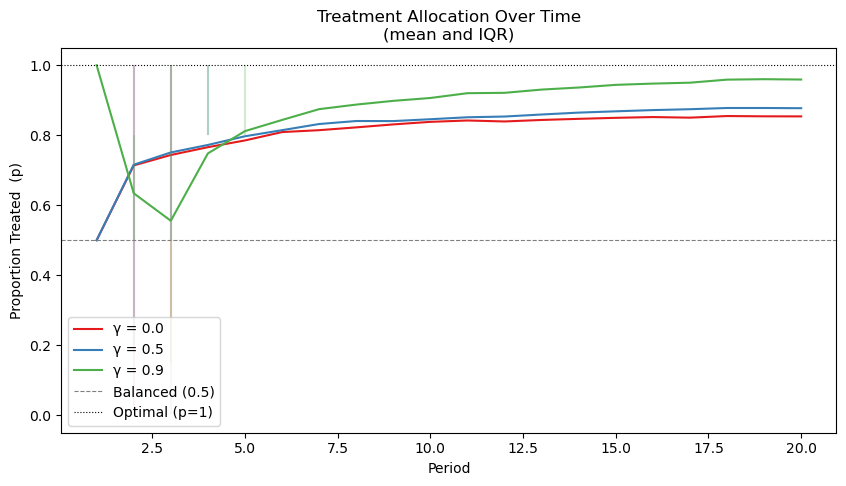

In [14]:
periods = np.arange(1, T_sim + 1)
colors  = {0.0: '#e41a1c', 0.5: '#377eb8', 0.9: '#4daf4a'}

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# ── Plot 1: Treatment Allocation ──────────────────────────────────────────────
for g in gamma_values:
    m = results[g]['alloc'].mean(axis=0)
    p25 = np.quantile(results[g]['alloc'], q=0.25, axis=0)
    p75 = np.quantile(results[g]['alloc'], q=0.75, axis=0)

    ax.plot(periods, m, color=colors[g], label=f'γ = {g}')
    ax.vlines(x=periods, ymin=p25, ymax=p75, color=colors[g], alpha=0.25)

ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8, label='Balanced (0.5)')
ax.axhline(1.0, linestyle=':',  color='black', linewidth=0.8, label='Optimal (p=1)')
ax.set_title('Treatment Allocation Over Time\n(mean and IQR)')
ax.set_xlabel('Period')
ax.set_ylabel('Proportion Treated  (p)')
ax.set_ylim(-0.05, 1.05)
ax.legend()


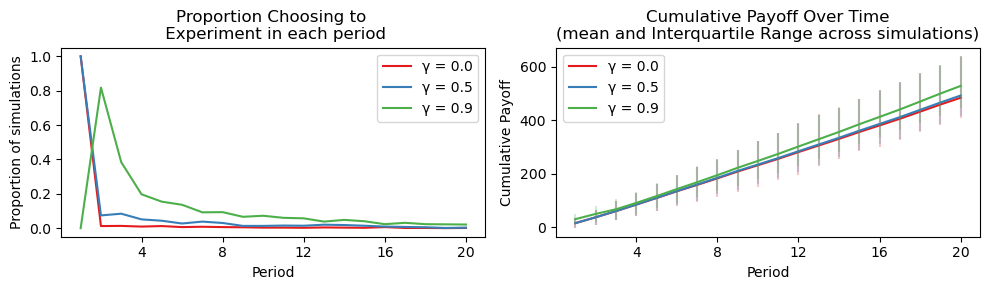

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

for g in gamma_values:
    prop = ((results[g]['alloc']!=1) & (results[g]['alloc']!=0)).mean(axis=0)
    ax[0].plot(periods, prop, color=colors[g], label=f'γ = {g}')
ax[0].set_title(f'Proportion Choosing to \n Experiment in each period')
ax[0].set_xlabel('Period')
ax[0].set_ylabel('Proportion of simulations')
ax[0].set_ylim(-0.05, 1.05)
ax[0].set_xticks([e for e in periods if e%4==0])
ax[0].legend()


for g in gamma_values:
    m = results[g]['cumrew'].mean(axis=0)
    p25 = np.quantile(results[g]['cumrew'], q=0.25, axis=0)
    p75 = np.quantile(results[g]['cumrew'], q=0.75, axis=0)

    ax[1].plot(periods, m, color=colors[g], label=f'γ = {g}')
    ax[1].vlines(x=periods, ymin=p25, ymax=p75, color=colors[g], alpha=0.25)

ax[1].set_title('Cumulative Payoff Over Time\n(mean and Interquartile Range across simulations)')
ax[1].set_xlabel('Period')
ax[1].set_ylabel('Cumulative Payoff')
ax[1].set_xticks([e for e in periods if e%4==0])
ax[1].legend()

plt.tight_layout()
plt.savefig('preference_experimentation_v2.png', dpi=150, bbox_inches='tight')
plt.show()


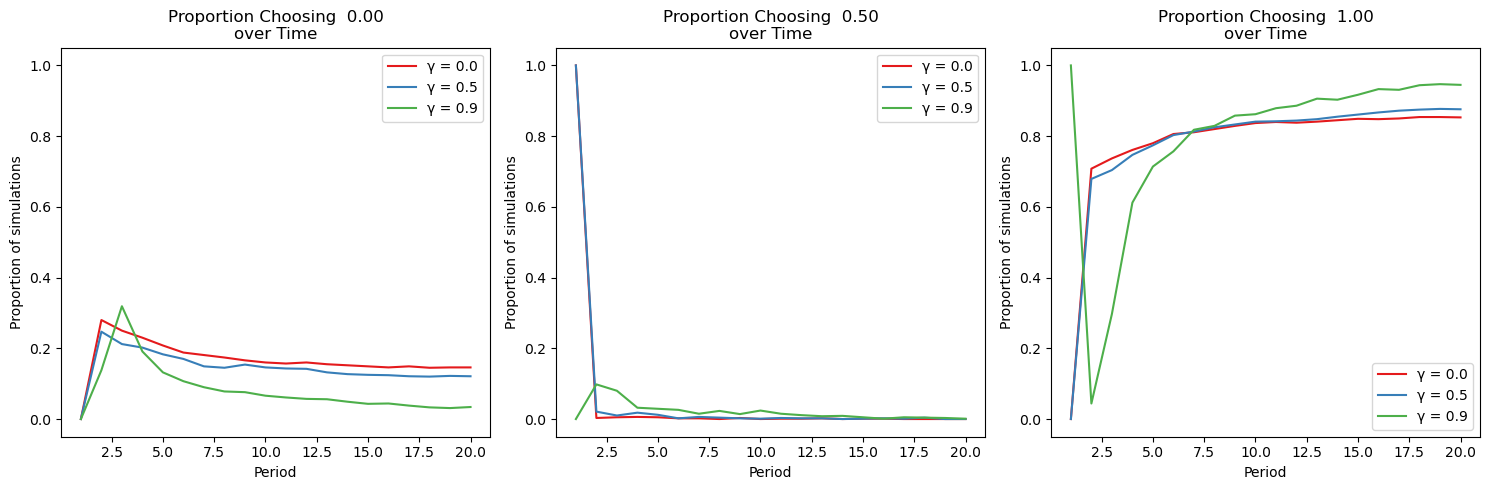

In [16]:
specific_allocations = [0.0, 0.5, 1.0]
fig, axes = plt.subplots(1, len(specific_allocations)
                         , figsize=(5*len(specific_allocations), 5))

for ax, target_p in zip(axes, specific_allocations):
    for g in gamma_values:
        prop = (results[g]['alloc'] == target_p).mean(axis=0)
        ax.plot(periods, prop, color=colors[g], label=f'γ = {g}')
    ax.set_title('Proportion Choosing {0:5.2f}\nover Time'.format(target_p))
    ax.set_xlabel('Period')
    ax.set_ylabel('Proportion of simulations')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()